<a href="https://colab.research.google.com/github/Nightnare96/Predective-Modeling-For-E-Commerce-Customer-Churn/blob/main/Warehouse_Location_Optimization_using_MILP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import zipfile
import os

zip_ref = zipfile.ZipFile('/content/archive (2).zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

Status: Optimal
Total Cost: 548.8302544198359

Opened Warehouses: ['Los Angeles']

Customer Assignments:
New York City → Los Angeles
Los Angeles → Los Angeles
San Francisco → Los Angeles
Seattle → Los Angeles
Philadelphia → Los Angeles
Houston → Los Angeles
Chicago → Los Angeles
Columbus → Los Angeles
San Diego → Los Angeles
Detroit → Los Angeles


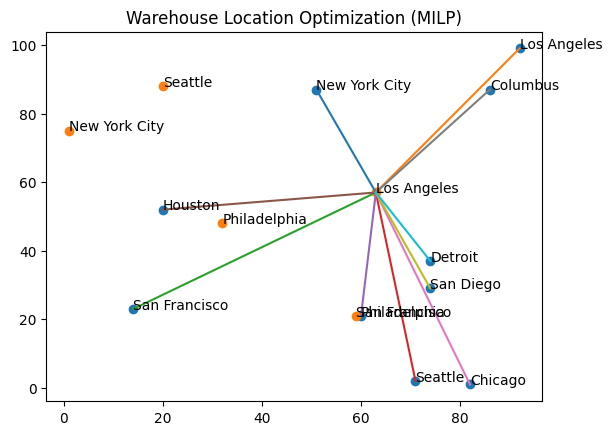

In [10]:
import pandas as pd
import numpy as np
import pulp
import matplotlib.pyplot as plt

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_excel("/content/SuperStore Sales DataSet.xlsx")

# Clean column names (important for Kaggle dataset)
df.columns = df.columns.str.strip()

# -----------------------------
# Preprocessing
# -----------------------------
# Aggregate demand by city
demand_df = df.groupby('City')['Sales'].sum().reset_index()
demand_df.columns = ['City', 'Demand']

# Select top cities as customers
customers = demand_df.sort_values(by='Demand', ascending=False).head(10)

# Select warehouse candidates (top demand cities)
warehouses = customers.head(5).copy()

# Assign coordinates (for visualization)
np.random.seed(42)
customers['x'] = np.random.randint(0, 100, len(customers))
customers['y'] = np.random.randint(0, 100, len(customers))

warehouses['x'] = np.random.randint(0, 100, len(warehouses))
warehouses['y'] = np.random.randint(0, 100, len(warehouses))

# Fixed cost for warehouses
warehouses['fixed_cost'] = np.random.randint(80, 150, len(warehouses))

# -----------------------------
# Cost Matrix (Distance)
# -----------------------------
cost = {}
for _, w in warehouses.iterrows():
    for _, c in customers.iterrows():
        dist = np.sqrt((w['x'] - c['x'])**2 + (w['y'] - c['y'])**2)
        cost[(w['City'], c['City'])] = dist

# -----------------------------
# MILP Model
# -----------------------------
W = warehouses['City'].tolist()
C = customers['City'].tolist()

fixed_cost = dict(zip(warehouses['City'], warehouses['fixed_cost']))

model = pulp.LpProblem("Warehouse_Location", pulp.LpMinimize)

# Decision Variables
x = pulp.LpVariable.dicts("assign",
                          [(i, j) for i in W for j in C],
                          0, 1, pulp.LpBinary)

y = pulp.LpVariable.dicts("open", W, 0, 1, pulp.LpBinary)

# Objective Function
model += (
    pulp.lpSum(fixed_cost[i] * y[i] for i in W) +
    pulp.lpSum(cost[(i, j)] * x[(i, j)] for i in W for j in C)
)

# Constraints

# Each customer assigned once
for j in C:
    model += pulp.lpSum(x[(i, j)] for i in W) == 1

# Assign only if warehouse is open
for i in W:
    for j in C:
        model += x[(i, j)] <= y[i]

# -----------------------------
# Solve
# -----------------------------
model.solve()

# -----------------------------
# Results
# -----------------------------
print("Status:", pulp.LpStatus[model.status])
print("Total Cost:", pulp.value(model.objective))

open_warehouses = []
assignments = []

for i in W:
    if y[i].value() == 1:
        open_warehouses.append(i)

for i in W:
    for j in C:
        if x[(i, j)].value() == 1:
            assignments.append((i, j))

print("\nOpened Warehouses:", open_warehouses)

print("\nCustomer Assignments:")
for a in assignments:
    print(f"{a[1]} → {a[0]}")

# -----------------------------
# Visualization
# -----------------------------
plt.figure()

# Plot customers
plt.scatter(customers['x'], customers['y'])
for _, row in customers.iterrows():
    plt.text(row['x'], row['y'], row['City'])

# Plot warehouses
plt.scatter(warehouses['x'], warehouses['y'])
for _, row in warehouses.iterrows():
    plt.text(row['x'], row['y'], row['City'])

# Draw assignment lines
for (w, c) in assignments:
    wx = warehouses[warehouses['City'] == w]['x'].values[0]
    wy = warehouses[warehouses['City'] == w]['y'].values[0]
    cx = customers[customers['City'] == c]['x'].values[0]
    cy = customers[customers['City'] == c]['y'].values[0]

    plt.plot([wx, cx], [wy, cy])

plt.title("Warehouse Location Optimization (MILP)")
plt.show()